# seoul bike demand — first look
Quick pass over the data before building any of the pipeline. I just want to
understand the target, see which features actually matter, and get a baseline
error number to beat once lightgbm goes into the training stage.

Working off the reference window (Dec 2017 – Aug 2018) that the ingest stage wrote out.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/reference.csv", parse_dates=["date"])
df.shape

(6576, 14)

In [2]:
df.head()

,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,season,holiday,functioning_day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df.describe().round(2)

,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall
count,6576,6576.00,6576.00,6576.00,6576.00,6576.00,6576.00,6576.00,6576.00,6576.00,6576.00
mean,2018-04-16 12:00:00,666.41,11.50,12.47,57.89,1.80,1395.67,3.60,0.58,0.16,0.08
min,2017-12-01 00:00:00,0.00,0.00,-17.80,0.00,0.00,27.00,-30.60,0.00,0.00,0.00
25%,2018-02-07 00:00:00,186.00,5.75,1.20,42.00,1.00,880.75,-7.60,0.00,0.00,0.00
50%,2018-04-16 12:00:00,419.00,11.50,13.60,57.00,1.60,1604.50,4.70,0.02,0.00,0.00
75%,2018-06-24 00:00:00,993.00,17.25,23.70,74.00,2.50,1987.00,16.20,0.94,0.00,0.00
max,2018-08-31 00:00:00,3556.00,23.00,39.40,98.00,7.40,2000.00,27.20,3.52,35.00,5.10
std,NaN,638.45,6.92,13.15,20.88,1.06,616.23,14.35,0.89,1.18,0.42


## target
`rented_bike_count` is what we predict. It's heavily right-skewed, so a log
transform looks worth keeping in mind for the model later.

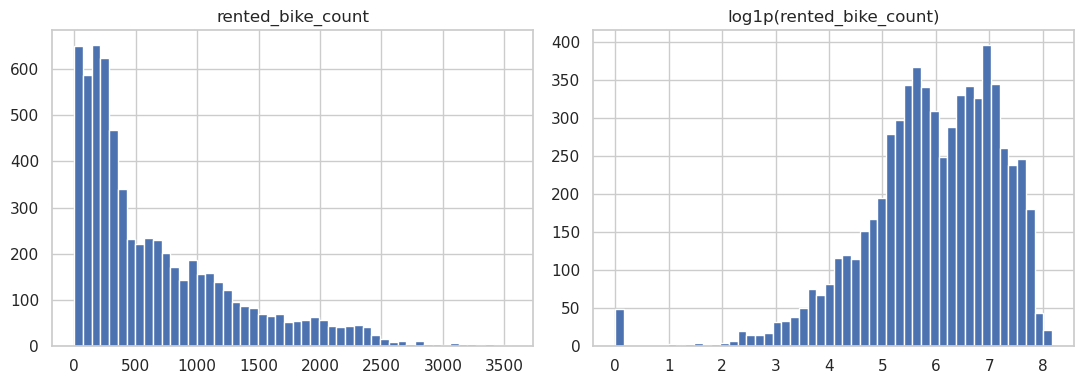

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["rented_bike_count"].hist(bins=50, ax=ax[0])
ax[0].set_title("rented_bike_count")
np.log1p(df["rented_bike_count"]).hist(bins=50, ax=ax[1])
ax[1].set_title("log1p(rented_bike_count)")
plt.tight_layout()

## the functioning-day quirk
On days the system isn't operating the count is always 0. Those rows are noise
for a demand model, so I'll drop them before training.

In [5]:
df.groupby("functioning_day")["rented_bike_count"].agg(["count", "mean"])

,count,mean
functioning_day,,
No,48,0.000000
Yes,6528,671.310049


## when do people ride
Demand follows the commute — two peaks around 8am and 6pm — and the whole curve
lifts in summer. Hour and season clearly carry signal.

/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: Whe

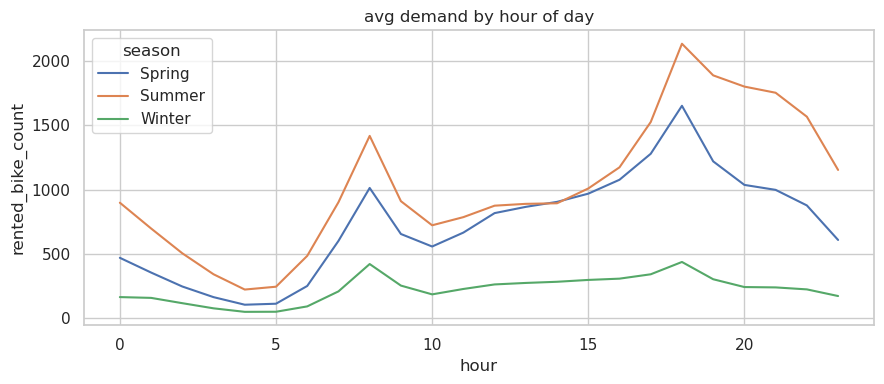

In [6]:
hourly = df.groupby(["season", "hour"])["rented_bike_count"].mean().reset_index()
plt.figure(figsize=(9, 4))
sns.lineplot(data=hourly, x="hour", y="rented_bike_count", hue="season")
plt.title("avg demand by hour of day")
plt.tight_layout()

## weather
Temperature is the strongest weather driver. Dew point tracks it closely (they'll
be collinear), and rain/snow mostly push demand down.

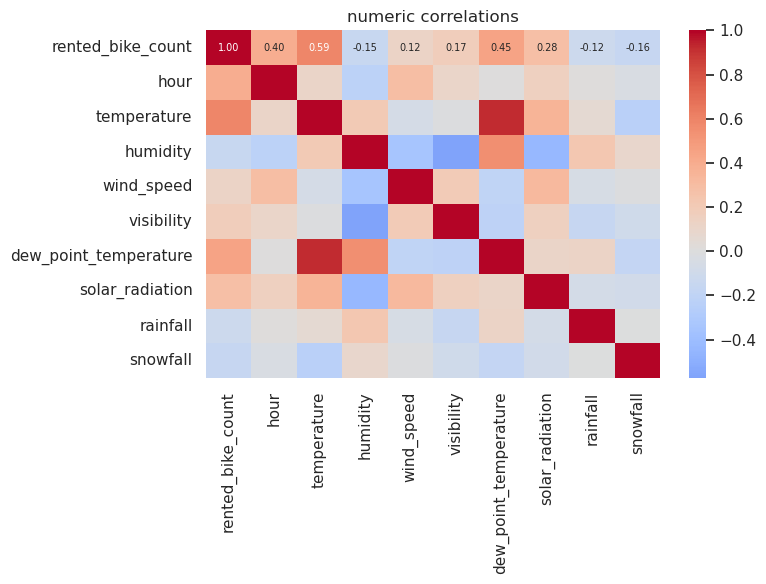

In [7]:
num = df.select_dtypes("number")
plt.figure(figsize=(8, 6))
sns.heatmap(num.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7})
plt.title("numeric correlations")
plt.tight_layout()

## the shift I care about for monitoring
The current window (Sep–Nov) is colder than the training window, and it's almost
entirely autumn — a season the training window barely sees. That distribution gap
is exactly what the drift monitoring should pick up once it's in place.

/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


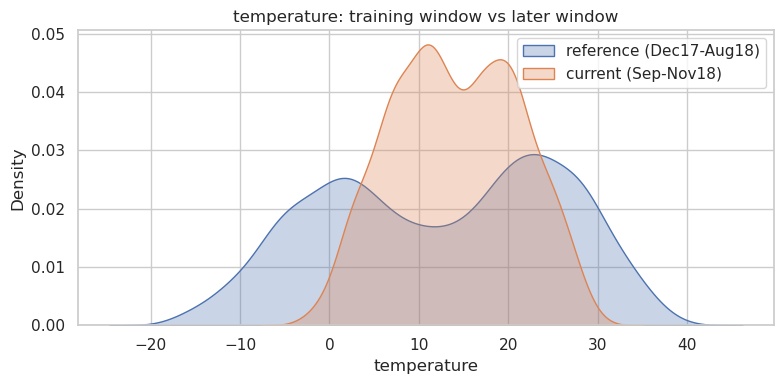

In [8]:
cur = pd.read_csv("../data/processed/current.csv", parse_dates=["date"])
plt.figure(figsize=(8, 4))
sns.kdeplot(x=df["temperature"], label="reference (Dec17-Aug18)", fill=True, alpha=.3)
sns.kdeplot(x=cur["temperature"], label="current (Sep-Nov18)", fill=True, alpha=.3)
plt.legend()
plt.title("temperature: training window vs later window")
plt.tight_layout()

In [9]:
print("reference seasons:", sorted(df["season"].unique()))
print("current seasons:  ", sorted(cur["season"].unique()))

reference seasons: ['Spring', 'Summer', 'Winter']
current seasons:   ['Autumn']


## quick baseline
Random forest on a few one-hot features, with a time-ordered holdout (last 20% of
the window) rather than a random split — this is a time series. Whatever lightgbm
does in the training stage has to beat this.

In [10]:
d = df[df["functioning_day"] == "Yes"].copy()
d = pd.get_dummies(d, columns=["season", "holiday"], drop_first=True)
d = d.drop(columns=["functioning_day", "date"])
y = d.pop("rented_bike_count")

k = int(len(d) * 0.8)
Xtr, Xte, ytr, yte = d.iloc[:k], d.iloc[k:], y.iloc[:k], y.iloc[k:]

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(Xtr, ytr)
pred = rf.predict(Xte)
print("MAE ", round(mean_absolute_error(yte, pred), 1))
print("RMSE", round(mean_squared_error(yte, pred) ** 0.5, 1))
print("R2  ", round(r2_score(yte, pred), 3))

MAE  322.1
RMSE 429.5
R2   0.485


In [11]:
pd.Series(rf.feature_importances_, index=d.columns).sort_values(ascending=False).head(10)

temperature              0.485160
hour                     0.232742
humidity                 0.096631
solar_radiation          0.090337
rainfall                 0.031383
dew_point_temperature    0.018419
visibility               0.018416
wind_speed               0.015941
season_Winter            0.005399
season_Summer            0.002745
dtype: float64

## takeaways
- target is right-skewed; log1p is cleaner, worth trying in the model
- hour (two commute peaks) and temperature carry most of the signal
- non-functioning days are always zero — drop them before training
- dew point is basically a copy of temperature; no need for both
- the later window is colder and mostly autumn, a season barely in training — that
  gap is the drift the monitoring stage needs to flag
- baseline RF is the number to beat in the train stage